In [ ]:
# importing the libraries
import numpy as np
import pandas as pd

In [34]:
path = "intern_dataset_realistic (1).csv"

In [35]:
df = pd.read_csv(path)

In [36]:
df.head()

,Intern_ID,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,INT0001,3.26,4.09,86.50,70.98
1,INT0002,NaN,1.33,59.23,42.16
2,INT0003,5.78,NaN,42.98,49.89
3,INT0004,4.28,1.43,83.16,68.49
4,INT0005,1.53,1.91,74.10,77.51


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Intern_ID          10000 non-null  object 
 1   Completion_Time    9604 non-null   float64
 2   Feedback_Rating    9608 non-null   float64
 3   Attendance         9610 non-null   float64
 4   Performance_Score  10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


In [38]:
df.describe()

,Completion_Time,Feedback_Rating,Attendance,Performance_Score
count,9604.000000,9608.000000,9610.000000,10000.000000
mean,3.958567,2.909313,62.769768,67.808159
std,1.738279,1.312825,26.614348,15.170590
min,1.000000,1.000000,0.000000,25.950000
25%,2.460000,1.800000,52.692500,56.947500
50%,3.920000,2.870000,66.830000,67.830000
75%,5.450000,4.000000,82.857500,78.870000
max,7.000000,5.000000,100.000000,100.000000


In [39]:
# we dont need id as it is label 
df = df.drop(columns = ["Intern_ID"])

In [40]:
df.head()

,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,3.26,4.09,86.50,70.98
1,NaN,1.33,59.23,42.16
2,5.78,NaN,42.98,49.89
3,4.28,1.43,83.16,68.49
4,1.53,1.91,74.10,77.51


In [41]:
#dealing with missing values
df.isnull().any()

Completion_Time       True
Feedback_Rating       True
Attendance            True
Performance_Score    False
dtype: bool

In [42]:
df.isnull().sum()

Completion_Time      396
Feedback_Rating      392
Attendance           390
Performance_Score      0
dtype: int64

In [43]:
# caluculating percentage of missing values 
df.isnull().sum()/len(df) * 100

Completion_Time      3.96
Feedback_Rating      3.92
Attendance           3.90
Performance_Score    0.00
dtype: float64

In [44]:
# check if missing values are random
print(df[df["Completion_Time"].isnull()]["Performance_Score"].describe())
print(df[df["Feedback_Rating"].isnull()]["Performance_Score"].describe())

count    396.000000
mean      67.957576
std       14.474773
min       28.290000
25%       58.567500
50%       67.900000
75%       78.267500
max      100.000000
Name: Performance_Score, dtype: float64
count    392.000000
mean      67.294413
std       14.733806
min       34.500000
25%       57.010000
50%       67.095000
75%       76.370000
max      100.000000
Name: Performance_Score, dtype: float64


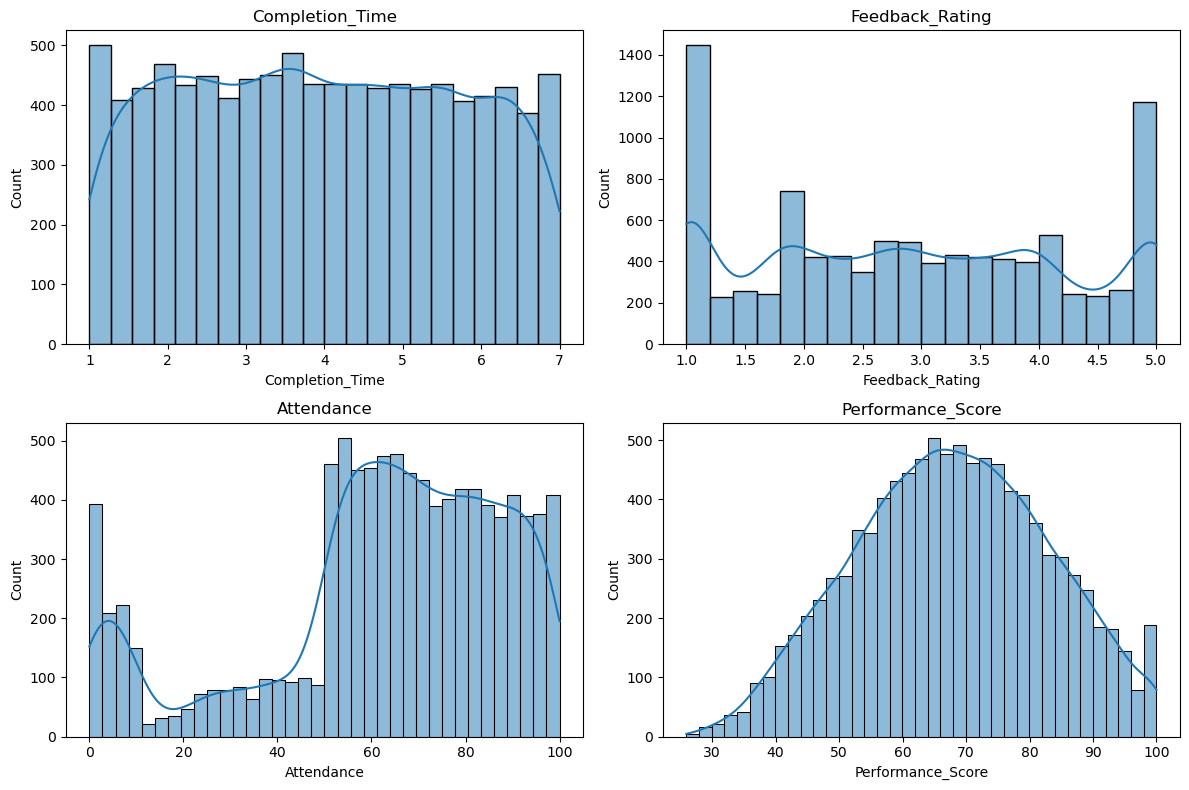

In [45]:
#Visualize distribution of every feature 

import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Completion_Time", "Feedback_Rating", "Attendance", "Performance_Score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [46]:
# missing values have no hidden confession (mean good and std is good ,i.e no MNAR detected)
# percentage of missing values is less we can easily apply mean.mode and median 
# but the better approach will be KNN imputer

from sklearn.impute import KNNImputer

features_to_impute = ["Completion_Time","Feedback_Rating","Attendance"]
imputer = KNNImputer(n_neighbors  = 5)
df[features_to_impute] = imputer.fit_transform(df[features_to_impute])
print(df.isnull().sum())

Completion_Time      0
Feedback_Rating      0
Attendance           0
Performance_Score    0
dtype: int64


In [47]:
df.head()

,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,3.260,4.090,86.50,70.98
1,4.852,1.330,59.23,42.16
2,5.780,3.324,42.98,49.89
3,4.280,1.430,83.16,68.49
4,1.530,1.910,74.10,77.51


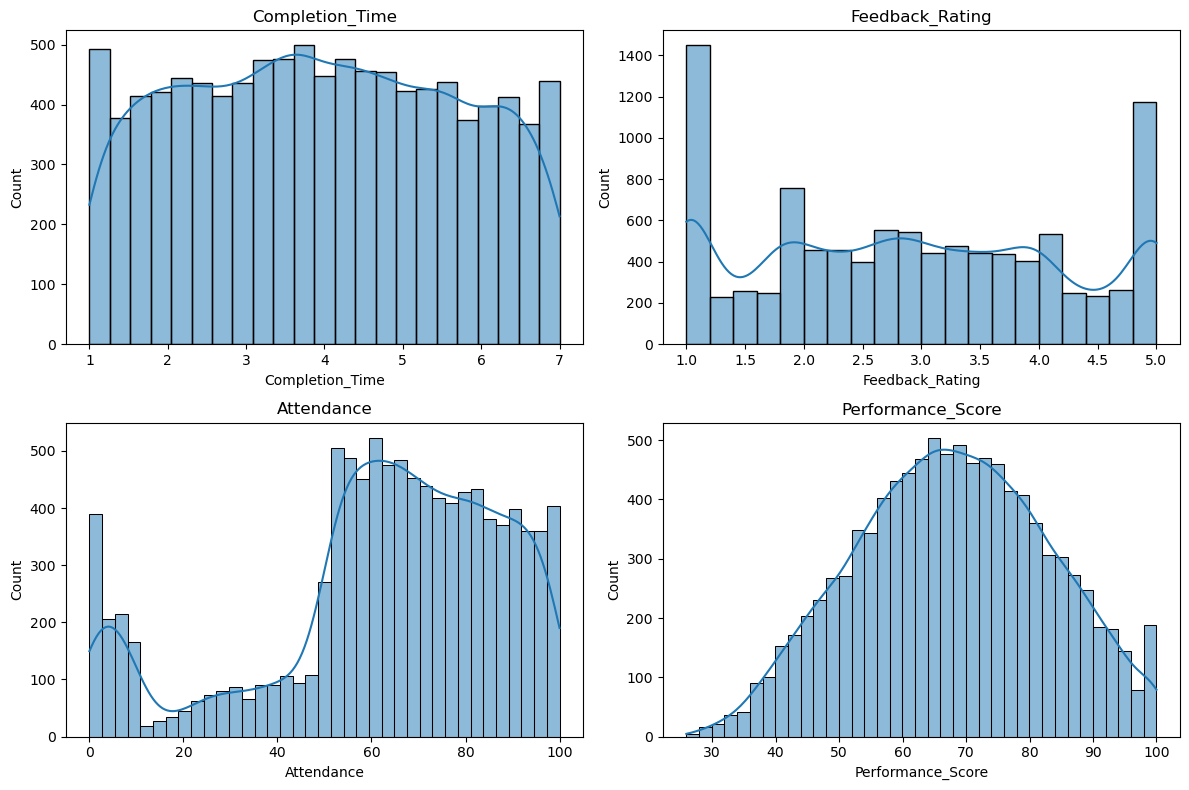

In [48]:
cols = ["Completion_Time", "Feedback_Rating", "Attendance", "Performance_Score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

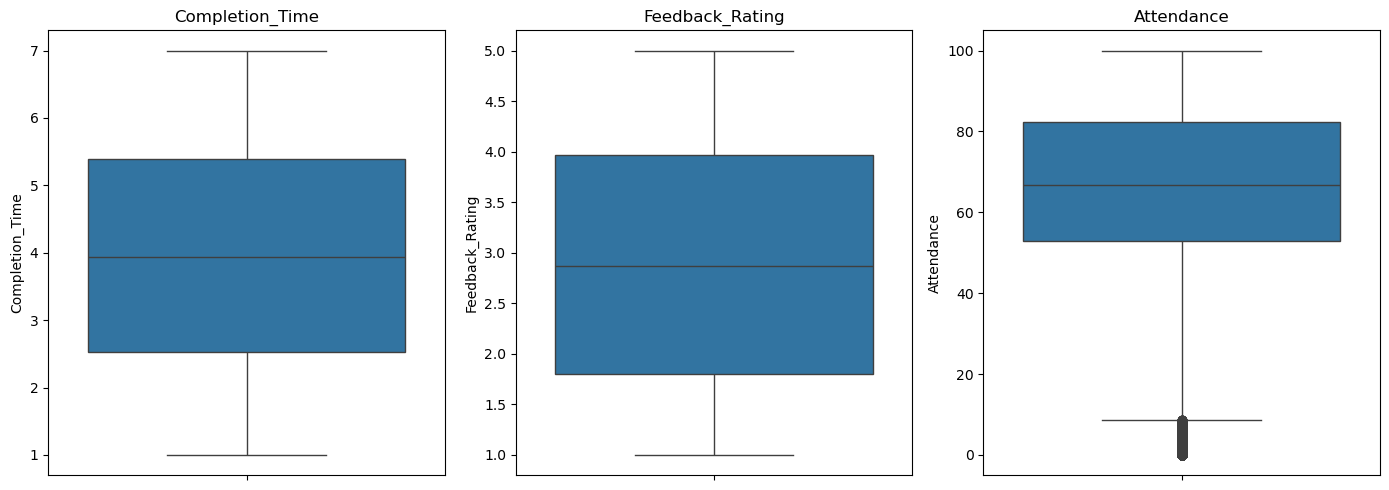

In [49]:
# detecting the outliers 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ["Completion_Time", "Feedback_Rating", "Attendance"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [50]:
# Look at the performance of the worst attendance outliers
print(df[df["Attendance"] < 5][["Attendance", "Completion_Time", "Performance_Score"]].head(10))

     Attendance  Completion_Time  Performance_Score
10         0.00             1.00              95.37
29         3.33             1.69              78.86
42         1.76             1.21              73.71
62         4.95             6.22              66.57
72         4.77             1.36              85.98
87         1.95             4.43              54.52
100        0.32             1.33             100.00
151        0.00             2.58              55.82
229        3.74             4.44              56.87
232        3.34             4.78              87.76


In [51]:
# Drop rows where HR attendance data is clearly corrupted (less than 5%)
# but performance scores indicate they were actually working.
df = df[df["Attendance"] >= 5.0]

print(f"Clean dataset size: {len(df)} rows")

Clean dataset size: 9435 rows


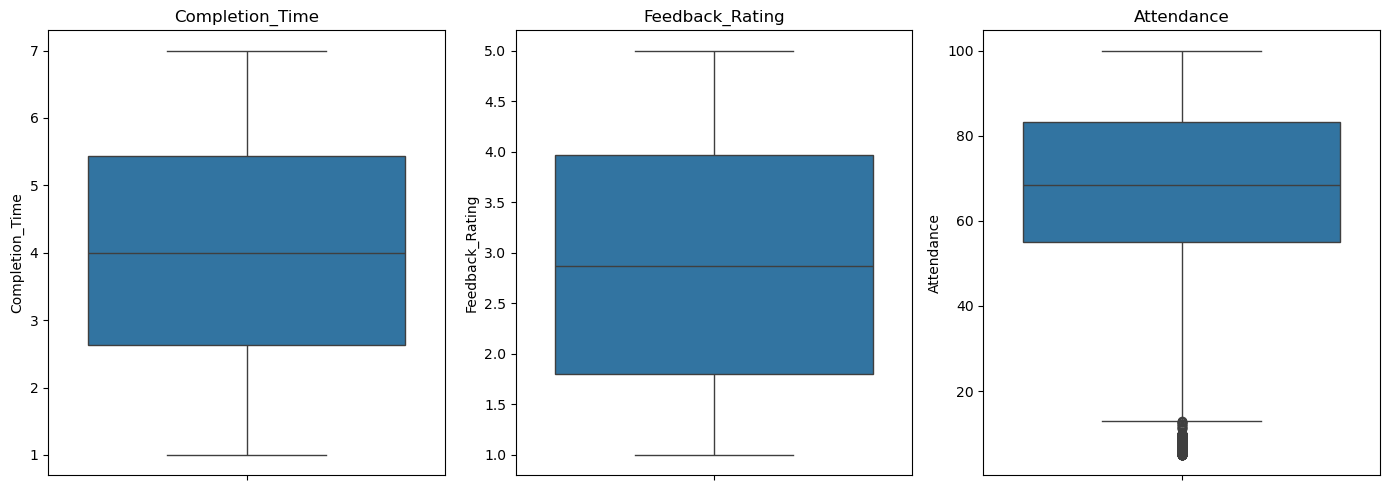

In [52]:
# detecting the outliers 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ["Completion_Time", "Feedback_Rating", "Attendance"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

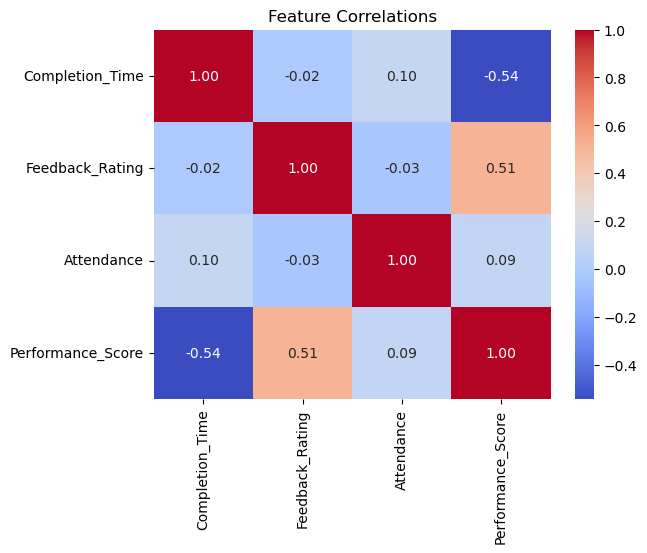

In [54]:
# Correlation Heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

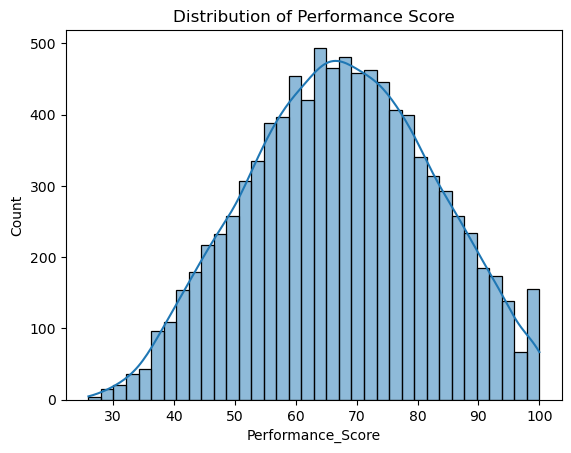

Skewness: -0.03186346599809702


In [55]:
#visualizing target variable specifically
sns.histplot(df["Performance_Score"], kde=True)
plt.title("Distribution of Performance Score")
plt.show()

print("Skewness:", df["Performance_Score"].skew())

In [57]:
## skewness almost equal to zero so it is good and we also see a bell curve therefore no bias problem

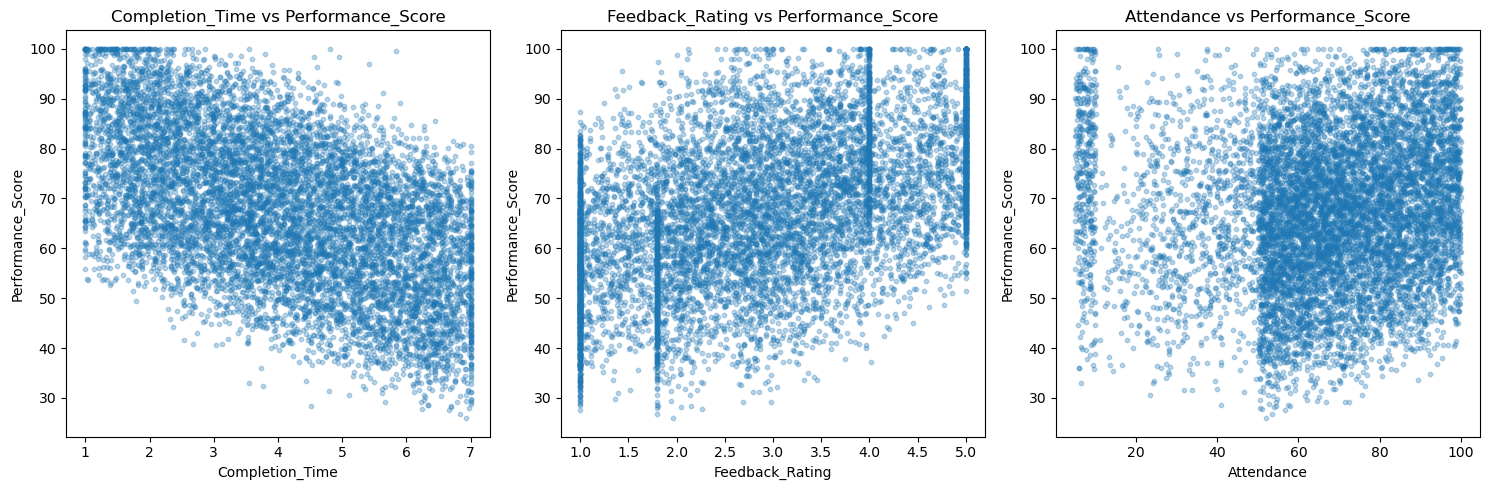

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["Completion_Time", "Feedback_Rating", "Attendance"]):
    ax.scatter(df[col], df["Performance_Score"], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Performance_Score")
    ax.set_title(f"{col} vs Performance_Score")
plt.tight_layout()
plt.show()

In [59]:
# Create the engineered feature
df["Efficiency_Score"] = df["Feedback_Rating"] / df["Completion_Time"]

# Test it against the Performance Score
efficiency_corr = df[["Efficiency_Score", "Performance_Score"]].corr().iloc[0, 1]
print(f"Efficiency_Score Correlation: {efficiency_corr:.2f}")

Efficiency_Score Correlation: 0.64
